Primero analicemos un conjunto de imágenes simples que consiste solamente en imágenes de dígitos escritos a mano en blanco y negro de tamaño 28x28 pixels en 10 categorías del 0-9.

Usaremos el conjunto de datos MNIST que contiene 60,000 imágenes, más 10,000 imágenes de prueba.

In [16]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [17]:
#El lote de imagenes es  un array de números enteros
train_images.dtype, train_images.shape

(dtype('uint8'), (60000, 28, 28))

In [18]:
#Las etiquetas es un arreglo que contiene el número correspondiente a cada imagen
len(train_labels), train_labels.dtype

(60000, dtype('uint8'))

In [19]:
train_labels, train_images[0]

(array([5, 0, 4, ..., 5, 6, 8], dtype=uint8),
 array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          18,  18,  18, 126, 136, 175,  

<function matplotlib.pyplot.show(close=None, block=None)>

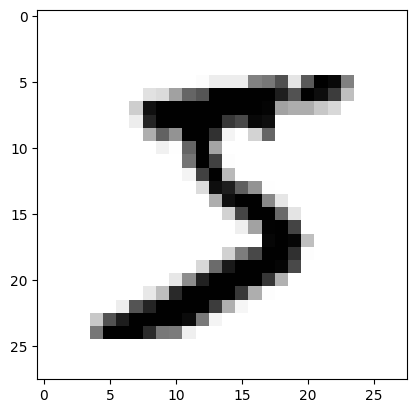

In [20]:
import matplotlib.pyplot as plt

#Veamos como se ven los ejemplos
plt.imshow(train_images[0], cmap=plt.cm.binary)
plt.show

Vemos que la codificación de la imágen muestra en negro al 0 y en blanco al 255, por lo que para normalizar podríamos solo dividir entre 255.

In [21]:
#Convertimos la imágen al formato de tensor normalizado
import torch

train_images_t = torch.tensor(train_images)/255
train_labels_t = torch.tensor(train_labels)
test_images_t = torch.tensor(test_images[0:500])/255
test_labels_t = torch.tensor(test_labels[0:500])

train_images_t.dtype, train_images_t.shape, train_labels_t.shape

(torch.float32, torch.Size([60000, 28, 28]), torch.Size([60000]))

Sin embargo, necesitamos convertir este arreglo de tal forma que las imagenes en ves de verse como matrices se vean como renglones, en particular vectores renglon, para esto podemos recurrir a la siguiente forma:

In [22]:
len(train_labels_t)

60000

In [23]:
#Cambiamos su forma a vector las imágenes
tr_img_v = torch.reshape(train_images_t, (60000, 28*28))
test_img_v = torch.reshape(test_images_t, (500, 28*28))
tr_img_v, tr_img_v.shape

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 torch.Size([60000, 784]))

En cuanto a los datos de salida, estos son datos numéricos claro, pero la información importante no está ni en su valor ni en su orden respecto a los otros, por lo que los trataremos como variables categóricas (aunque se puede siempre dejar igual)

In [24]:
#Creamos el tensor de etiquetas
tr_img_t = tr_img_v[0:1000]
tr_labels_t = train_labels_t[0:1000]

one_hot_labels = torch.zeros(len(tr_labels_t),10)
one_hot_testlabels = torch.zeros(len(test_labels_t),10)

#Codificamos la información en cada renglón
for i,j in enumerate(tr_labels_t):
    j = int(j)
    one_hot_labels[i,j] = 1.0

for i,j in enumerate(test_labels_t):
    j = int(j)
    one_hot_testlabels[i,j] = 1.0

tr_labels = one_hot_labels
test_labels = one_hot_testlabels
tr_labels

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

Usaremos ahora otro tipo de función de activación llamada RELU pues esto nos permite quitarle importancia los valores negativos y así quedarnos con valores siempre positivos. Además, como la respuesta final está acotada entre los valores de 0-9, usaremos la función regularizadora softmax en la última capa.

Como es usual, los tensores de entrada puden tener dimensiones a lo largo de las cuales codifican las probabilidades y otras en las cuales no, esto nos requier especificar la dimensio a través de la cual la función será aplicada

In [96]:
#El módulo nn ya cuenta con softmax 
softmax = nn.Softmax(dim=1)      #Localculara renglon por renglon

x = torch.tensor([[1.0, 2.0, 3.0],
                  [1.0, 2.0, 3.0]])

softmax(x)

tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])

In [97]:
#Procedemos a construir un modelo
import torch.nn as nn
from collections import OrderedDict

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(784, 40)),
    ('hidden_activation', nn.ReLU()),
    ('output_linear', nn.Linear(40,10)),
    ('output_activation', nn.Softmax(dim=1))
    ]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=784, out_features=40, bias=True)
  (hidden_activation): ReLU()
  (output_linear): Linear(in_features=40, out_features=10, bias=True)
  (output_activation): Softmax(dim=1)
)

Vamos a analizar como se comporta el entrenamiento en cuanto a la presición para predecir imágenes y no ya en cuanto a el error cuadrático médio, esto nos dará quizas una mejor idea de qe tan bueno es nuestro modelo.

In [98]:
def training_loop(n_epochs, optimizer, model, loss_fn, tr_img_t, tr_labels, test_img_v, test_labels):
    for epoch in range(1, n_epochs +1):
        correct_cnt = 0
        test_correct_cnt = 0
    
        labels_p = model(tr_img_t)
        train_loss = loss_fn(labels_p,tr_labels)

        labels_pv = model(test_img_v)
        val_loss = loss_fn(labels_pv,test_labels)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            for k in range(1000):
                test_correct_cnt += torch.argmax(seq_model(tr_img_t)[k]) == torch.argmax(tr_labels[k])
                
            for k in range(500):
                correct_cnt += torch.argmax(seq_model(test_img_v)[k]) == torch.argmax(test_labels[k])
                
            
            print("\n"+ "I:" + str(epoch) + \
                             " Test-Acc:"+str(test_correct_cnt/float(1000))+\
                             " Train-Acc:" + str(correct_cnt/500))

In [99]:
import torch.optim as optim 

optimizer = optim.SGD(seq_model.parameters(), lr=7e-1 )

training_loop(
    n_epochs = 300,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    tr_img_t = tr_img_t,
    tr_labels = tr_labels,
    test_img_v = test_img_v,
    test_labels = test_labels)


I:10 Test-Acc:tensor(0.2100) Train-Acc:tensor(0.1480)

I:20 Test-Acc:tensor(0.3000) Train-Acc:tensor(0.1940)

I:30 Test-Acc:tensor(0.4100) Train-Acc:tensor(0.3220)

I:40 Test-Acc:tensor(0.4760) Train-Acc:tensor(0.4020)

I:50 Test-Acc:tensor(0.5480) Train-Acc:tensor(0.4400)

I:60 Test-Acc:tensor(0.5760) Train-Acc:tensor(0.4760)

I:70 Test-Acc:tensor(0.6030) Train-Acc:tensor(0.5040)

I:80 Test-Acc:tensor(0.6130) Train-Acc:tensor(0.5180)

I:90 Test-Acc:tensor(0.6120) Train-Acc:tensor(0.5280)

I:100 Test-Acc:tensor(0.6110) Train-Acc:tensor(0.5280)

I:110 Test-Acc:tensor(0.6130) Train-Acc:tensor(0.5300)

I:120 Test-Acc:tensor(0.6100) Train-Acc:tensor(0.5340)

I:130 Test-Acc:tensor(0.6120) Train-Acc:tensor(0.5420)

I:140 Test-Acc:tensor(0.6240) Train-Acc:tensor(0.5600)

I:150 Test-Acc:tensor(0.6440) Train-Acc:tensor(0.5740)

I:160 Test-Acc:tensor(0.6600) Train-Acc:tensor(0.5840)

I:170 Test-Acc:tensor(0.6740) Train-Acc:tensor(0.6000)

I:180 Test-Acc:tensor(0.6840) Train-Acc:tensor(0.6120)



6


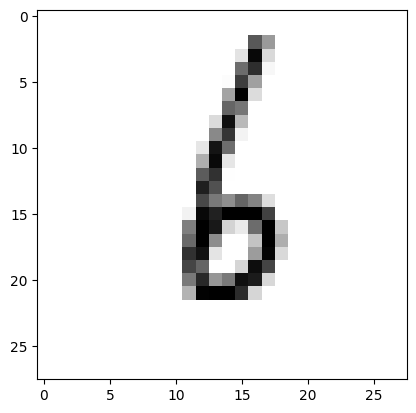

In [73]:
#Veamos como se ven los ejemplos
import random as rand

n = rand.randint(0,60000)
plt.imshow(train_images[n], cmap=plt.cm.binary)
plt.show

pred = seq_model(tr_img_v[n])

for i, x in enumerate(pred):
    if x == float(pred.max()):
        print(i)

Pasemos ahora a un problema más complejo en el cula ahora utilizaremos no solo imágenes con más pixeles, sino que estas representan objetos en sí y las imágenes tienen color.

In [1]:
from torchvision import datasets

#Descargamos la base de datos CIFAR10
data_path = '../data-unversioned'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
type(cifar10).__mro__

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [4]:
len(cifar10)

50000

In [10]:
# Definimos nombres de clase nombres de clase
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Tomar un ejemplo
img, label = cifar10[99]
img, label, class_names[label]

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

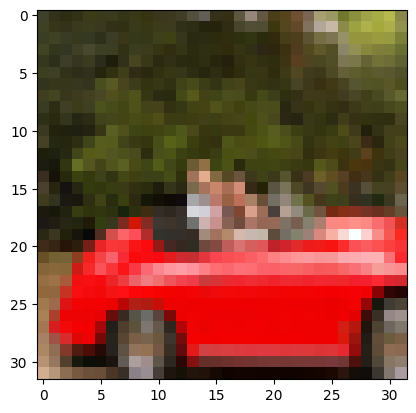

In [13]:
#Mostramos la imagen correspondiente
plt.imshow(img)
plt.show()

Puesto que esta base de datos es afin a torch podemos usar una de sus herramientas como transforms para convertir la imagen tipo PIL en un tensor. No solo sive para realizar transformaciones en tensores sino que también para hacer pequeñas modificaciones en la imagen.

In [74]:
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [75]:
#Hacemos una función solo para no escribir todo el comando y para ver su efecto
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [113]:
#Vamos a aplicarlo a todas las imagenes a la vez
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.ToTensor())

In [80]:
#Accediendo a cada elemento veremos que ahora es tipo tensor
img_t, _ = tensor_cifar10[99]
type(img_t), img_t.shape

(torch.Tensor, torch.Size([3, 32, 32]))

Hay que notar aquí que, mientras la imágen original las intensidades de cada color estaban formato 0-255, ahora al transformarlo a tensor automáticamente normalizó la imagen con valores de 0-1

In [81]:
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

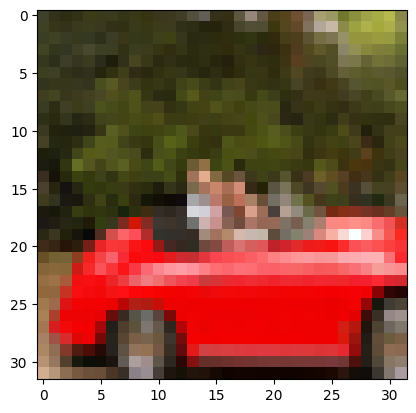

In [83]:
#Veamos que python la interpreta como la misma imagen
plt.imshow(img_t.permute(1,2,0))     #Veamos que tenemos que permutar porque el formato original es HXwXC
plt.show()

Ahora que ya hemos visto las funciones de activación en acción así como la normalización podemos hablar en mayor profundidad por qué son importantes más alla de ayudar en las características no lineales del modelado. Estas además ayudan a prevenir el sobre ajuste o memorización de la red restando importancia a ciertas neuronas y dándosela a otras. Más aun, cuando se escogen funciones de activacióon que son lineales cerca de 0 o -1 o 1, y mantienen los datos en un rango similar como tanh o relu, singifica que es más probable que las neuronas cerca de 0 tengan gradiente no nulo y así aprendan más rápidamente, por eso es importante la normalización tambien.

Adicionalmente, la normalización de cada canal de tal forma que cada uno tenga la misma distribución asegurará que la información de los canales puede ser mezclada y actualizada a través de SGD con el mismo learning rate.

In [114]:
#En lugar de normalizar como lo hicimos en el caso de la red neuronal de regresión usaremos transforms
#Primero formamos el bloque de imagenes como tensor
imgs =  torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
imgs.shape
#El proceso durará un rato

torch.Size([3, 32, 32, 50000])

In [87]:
#Calculamos ahora facilmente el promedio de cada canal
imgs.view(3, -1).mean(dim=1)
#Aquí cada imagen se convirtió en un vector con 3 canales y promediara sobre cada canal

tensor([0.4914, 0.4822, 0.4465])

In [86]:
#Calculamos la desviación estandar
imgs.view(3,-1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [88]:
#Ahora normalizamos con Normalize
transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))

Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))

In [115]:
#Y nuevamente importamos los datos de cifar usando Compose para aplicar varios procedimientos
transformed_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
]))
transformed_cifar10_val = datasets.CIFAR10(data_path, train=False, download=False, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


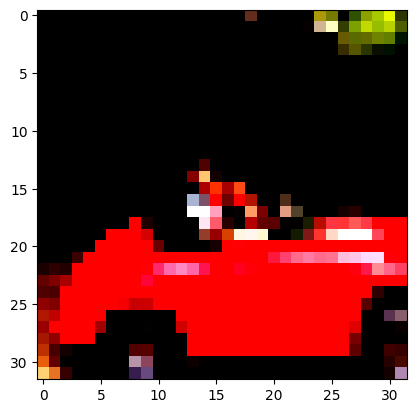

In [92]:
#La imagen ahora transformada ya no es la que era antes debido a esta normalización
img_t, _ = transformed_cifar10[99]
plt.imshow(img_t.permute(1,2,0))
plt.show()

A diferencia del problema anterior, ahora lo que haremos será solo tomar las imágenes de aves y de aviones y vamos a hacer una red neuronal que las distinga una de otra.

In [116]:
#Armamos el set de datos
label_map = {0:0, 2:1}           #Esto reetiqueta los elementos en cifar10 (estos ya estaban etiquetados)
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])           #Es un arreglo de tuplas no ordenado solo es un filtro
          for img, label in transformed_cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in transformed_cifar10_val
              if label in [0, 2]]
#Esto toma un ratito porque lo hace con las 50000 imágenes

In [157]:
imge, lbl = cifar2[0]
print(lbl) #El label nos dice que objeto es, si un avion 0 o un ave 1

1


In [162]:
len(cifar2)            #Esta es la cantidad de imagenes de aviones y aves

10000

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


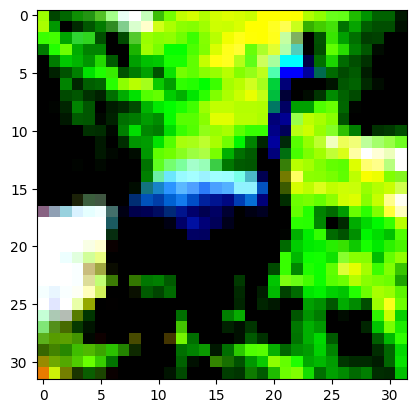

In [167]:
#Veamos una imagen de ave o del label 0
img, _ = cifar2[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


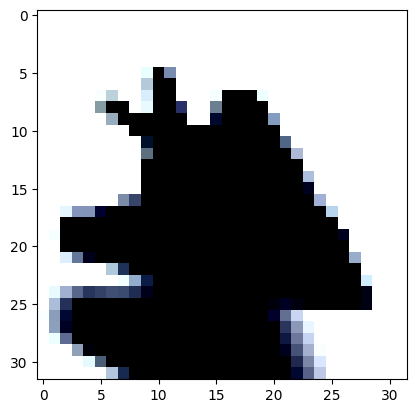

In [169]:
#Buscamos una imagen de avion
i = 0
for _, lbl in cifar2:
    if lbl == 0:
        break
    else:
        i += 1

img, _ = cifar2[i]

plt.imshow(img.permute(1, 2, 0))
plt.show()

In [170]:
#Escribimos el modelo
import torch.nn as nn

n_out = 2         #Es el número de parámetros de salida ave o avión

model = nn.Sequential(
        nn.Linear(3072, 512),           #Va a entrar un vector de 3x32x32
        nn.Tanh(),                      #La capa oculta tiene 512
        nn.Linear(512, n_out),
        nn.Softmax(dim=1))

In [119]:
#Para evaluar en el modelo primero debemos convertir la imagen en un vector para eso hacemos
img_batch = img.view(-1).unsqueeze(0)
img.shape, img.view(-1).shape, img_batch.shape
#Como vemos .view(-1) nos hace el trabajo de convertir la imagen tensor en un vector y unsqueeze lo hace renglon

(torch.Size([3, 32, 32]), torch.Size([3072]), torch.Size([1, 3072]))

In [171]:
out = model(img_batch)
out
#Lo que nos da una distribución de probabilidad entre las dos opciones que sumadas da 1

tensor([[0.3861, 0.6139]], grad_fn=<SoftmaxBackward0>)

In [172]:
#Nuevamente para saber qué valor predie, tomaremos el de mayor probabilidad
_, index = torch.max(out, dim=1)
index

tensor([1])

Sin embargo, a diferencia de como entrenamos la red neuronal que reconoce dígitos, ahora buscamos que la función de error "castigue" las clasificaciones erroneas y no su cercania a los valores de probabilidad buscados. Esta cantidad es llamada verosimilitud o likelihood. En otras palabras buscamos una función de error que sea muy grande cuando la verosimilitud sea baja: asi que las alternativas tienen mayor probabilidad. E inversamente es baja cuando la verosimilitud es baja. La función es llamada negative log likelihood (NLL).

In [173]:
#En torch se escribe con nn esta función de error así que el modelo 
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1))      #Cambiamos a LogSoftmax porque nos da mayor estabilidad en los cálculos

#Definimos la función de error
loss = nn.NLLLoss()

In [175]:
img, label = cifar2[0]

out = model(img.view(-1).unsqueeze(0))
print(out)

loss(out, torch.tensor([label]))

tensor([[-0.6716, -0.7151]], grad_fn=<LogSoftmaxBackward0>)


tensor(0.7151, grad_fn=<NllLossBackward0>)

In [177]:
#Pasamos a la función de entrenamiento
def training_loop(n_epochs, optimizer, model, loss_fn):
    for epoch in range(1, n_epochs +1):
        for img, label in cifar2:
            out = model(img.view(-1).unsqueeze(0))
            loss = loss_fn(out, torch.tensor([label]))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

In [178]:
#El entrenamiento
optimizer = optim.SGD(model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = nn.NLLLoss())

Epoch: 1, Loss: 0.088411
Epoch: 1, Loss: 1.152291
Epoch: 1, Loss: 1.600476
Epoch: 1, Loss: 0.025014
Epoch: 1, Loss: 0.384365
Epoch: 1, Loss: 0.100443
Epoch: 1, Loss: 4.518154
Epoch: 1, Loss: 4.521148
Epoch: 1, Loss: 0.187826
Epoch: 1, Loss: 3.061881
Epoch: 1, Loss: 0.016349
Epoch: 1, Loss: 2.845633
Epoch: 1, Loss: 0.007440
Epoch: 1, Loss: 2.026718
Epoch: 1, Loss: 0.120683
Epoch: 1, Loss: 0.100124
Epoch: 1, Loss: 3.965127
Epoch: 1, Loss: 0.840256
Epoch: 1, Loss: 0.107528
Epoch: 1, Loss: 0.061782
Epoch: 1, Loss: 2.663433
Epoch: 1, Loss: 0.057835
Epoch: 1, Loss: 1.283661
Epoch: 1, Loss: 1.430656
Epoch: 1, Loss: 0.365199
Epoch: 1, Loss: 0.971327
Epoch: 1, Loss: 2.135101
Epoch: 1, Loss: 0.092215
Epoch: 1, Loss: 0.802969
Epoch: 1, Loss: 0.077268
Epoch: 1, Loss: 0.280612
Epoch: 1, Loss: 0.227219
Epoch: 1, Loss: 0.624835
Epoch: 1, Loss: 0.073720
Epoch: 1, Loss: 2.172649
Epoch: 1, Loss: 0.010344
Epoch: 1, Loss: 0.425423
Epoch: 1, Loss: 0.094678
Epoch: 1, Loss: 0.226835
Epoch: 1, Loss: 0.017411


KeyboardInterrupt: 

El problema es que la función de entrenamiento actualiza el error con cada imagen en cada paso, pero hay muchísimas imágenes, lo que no es muy eficiente, pues alarga el proceso. La idea es, no usar todos los datos como hicimos con modelos anteriores y tampoco usar uno por uno en el proceso de aprendizaje, sino dividir todo el set de datos en paquetes de un tamaño adecuado tal que el proceso de aprendizaje se haga con cada paquete (que acumulen el gradiente y posteriormente actualicen el modelo

Resulta que usar gradientes estimados sobre paquetes, las cuales son aproximaciones más pobres que el gradiente estimado con todo el set, ayuda a la convergencia y previene que el proceso de optimización se atasque en mínimos locales que se encuentre en el proceso. El tamaño del paquete es un hiperparámetro asi como la velocidad de entrenamiento.

In [179]:
#Usamo torch para crear estos paquetes
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

In [180]:
#Cambiamos la función de entrenamiento
def training_loop(n_epochs, optimizer, model, loss_fn):
    for epoch in range(1, n_epochs +1):
        for imgs, labels in train_loader:
            batch_size = imgs.shape[0]
            outputs = model(imgs.view(batch_size,-1))
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

In [181]:
#Ahora entrenamos
training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = nn.NLLLoss())

Epoch: 1, Loss: 0.406682
Epoch: 2, Loss: 0.528658
Epoch: 3, Loss: 0.288798
Epoch: 4, Loss: 0.829815
Epoch: 5, Loss: 0.381554
Epoch: 6, Loss: 0.480609
Epoch: 7, Loss: 0.404016
Epoch: 8, Loss: 0.286270
Epoch: 9, Loss: 0.409216
Epoch: 10, Loss: 0.242353
Epoch: 11, Loss: 0.720247
Epoch: 12, Loss: 0.307764
Epoch: 13, Loss: 0.354110
Epoch: 14, Loss: 0.345581
Epoch: 15, Loss: 0.390994
Epoch: 16, Loss: 0.270867
Epoch: 17, Loss: 0.288708
Epoch: 18, Loss: 0.244280
Epoch: 19, Loss: 0.191763
Epoch: 20, Loss: 0.183437
Epoch: 21, Loss: 0.319855
Epoch: 22, Loss: 0.222476
Epoch: 23, Loss: 0.355764
Epoch: 24, Loss: 0.345243
Epoch: 25, Loss: 0.164185
Epoch: 26, Loss: 0.319734
Epoch: 27, Loss: 0.114078
Epoch: 28, Loss: 0.233829
Epoch: 29, Loss: 0.294496
Epoch: 30, Loss: 0.280995
Epoch: 31, Loss: 0.171420
Epoch: 32, Loss: 0.058075
Epoch: 33, Loss: 0.252189
Epoch: 34, Loss: 0.146067
Epoch: 35, Loss: 0.045173
Epoch: 36, Loss: 0.145171
Epoch: 37, Loss: 0.173184
Epoch: 38, Loss: 0.230425
Epoch: 39, Loss: 0.08